# 01 - Analyse Exploratoire (EDA) & Corrélations

**Jumeau Numérique Prédictif — Fours Sécheurs de Phosphate (OCP)**

Objectif de ce notebook : prendre en main le dataset, vérifier sa qualité,
analyser les séries temporelles et identifier les variables les plus corrélées
avec la consommation spécifique `Cs_Fuel` (cible, en kcal/t).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/donnees_four_ocp_2026.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date').sort_index()
df.head()

,Debit_Produit_Brut,Debit_Fuel,Cs_Fuel,Temp_Buse,Temp_Chambre,Temp_Entree_Filtre,Temp_Sortie_Filtre,Temp_Brique,Temp_Toile,Depression,Delta_P_Filtre,Pression_Air_Filtre,Courant_Virole,Poussiere,O2,CO,Temp_Flamme,Humidite_Phosphate,Temp_Fumees_Sortie
Date,,,,,,,,,,,,,,,,,,,
2026-02-01 00:00:00,264.901425,2039.984899,957.801814,867.660491,88.283642,85.474418,82.208774,282.497165,84.518123,-9.477954,84.612315,4.888103,87.960849,80.085979,5.806321,265.795499,1452.067785,13.351956,117.995340
2026-02-01 01:00:00,247.852038,1989.893024,962.599763,838.943936,73.666996,77.205494,82.485224,272.076472,80.930438,-7.192569,80.471406,4.021897,91.646371,72.629619,5.628543,316.955693,1365.992078,15.878908,118.549150
2026-02-01 02:00:00,273.430389,1900.358297,949.275535,846.181975,90.158341,85.788382,85.606138,268.621178,84.808563,-8.429099,79.421538,4.956824,84.461446,77.618872,5.833221,205.147548,1405.923787,16.179599,121.000919
2026-02-01 03:00:00,301.689996,2035.185098,953.353251,845.474002,77.424122,80.325713,86.309336,283.768234,92.584205,-7.922175,85.297593,5.189929,88.928425,77.236087,5.450763,281.503149,1399.865370,16.549362,121.792011
2026-02-01 04:00:00,250.973266,1946.357073,952.757584,853.143651,79.534804,79.936478,84.543054,273.872350,87.857928,-5.796699,73.929100,5.509636,91.002448,76.929585,5.509258,303.616813,1368.362897,12.974733,127.786302


In [3]:
print(f"Lignes : {df.shape[0]}  |  Colonnes : {df.shape[1]}")
print(f"Période : {df.index.min()} → {df.index.max()}")
print(f"Jours couverts : {df.index.floor("D").nunique()}")

print("\nValeurs manquantes :")
print(df.isnull().sum().sum(), "NaN au total")

print("\nTypes :")
print(df.dtypes)

Lignes : 4345  |  Colonnes : 19
Période : 2026-02-01 00:00:00 → 2026-08-01 00:00:00
Jours couverts : 182

Valeurs manquantes :
0 NaN au total

Types :
Debit_Produit_Brut     float64
Debit_Fuel             float64
Cs_Fuel                float64
Temp_Buse              float64
Temp_Chambre           float64
Temp_Entree_Filtre     float64
Temp_Sortie_Filtre     float64
Temp_Brique            float64
Temp_Toile             float64
Depression             float64
Delta_P_Filtre         float64
Pression_Air_Filtre    float64
Courant_Virole         float64
Poussiere              float64
O2                     float64
CO                     float64
Temp_Flamme            float64
Humidite_Phosphate     float64
Temp_Fumees_Sortie     float64
dtype: object


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Debit_Produit_Brut,4345.0,253.390296,142.108835,60.000000,111.351269,253.037927,390.418289,520.000000
Debit_Fuel,4345.0,2007.143313,368.877976,1220.534346,1671.430872,2004.173333,2335.936663,2903.145628
Cs_Fuel,4345.0,955.253040,38.908372,863.335263,927.647125,955.209922,980.416464,1061.185623
Temp_Buse,4345.0,856.966002,70.859524,750.000000,789.753996,862.284310,920.712356,980.000000
Temp_Chambre,4345.0,76.765415,10.996044,60.000000,66.652727,77.533296,86.267274,95.000000
Temp_Entree_Filtre,4345.0,76.811313,10.973829,60.000000,66.756309,77.452119,86.177889,95.000000
Temp_Sortie_Filtre,4345.0,85.206871,3.129895,80.000000,82.638920,85.278142,87.832371,90.000000
Temp_Brique,4345.0,280.925744,37.214769,200.000000,246.399011,283.232000,314.896296,350.000000
Temp_Toile,4345.0,90.524702,18.418405,60.000000,74.058905,91.293041,106.614221,120.000000
Depression,4345.0,-7.763512,3.798578,-15.000000,-11.117571,-7.486163,-4.491823,-1.500000


## Séries temporelles

Les variables suivent des évolutions lentes sur la période Février → Août 2026.
On trace la cible et les principales variables process.

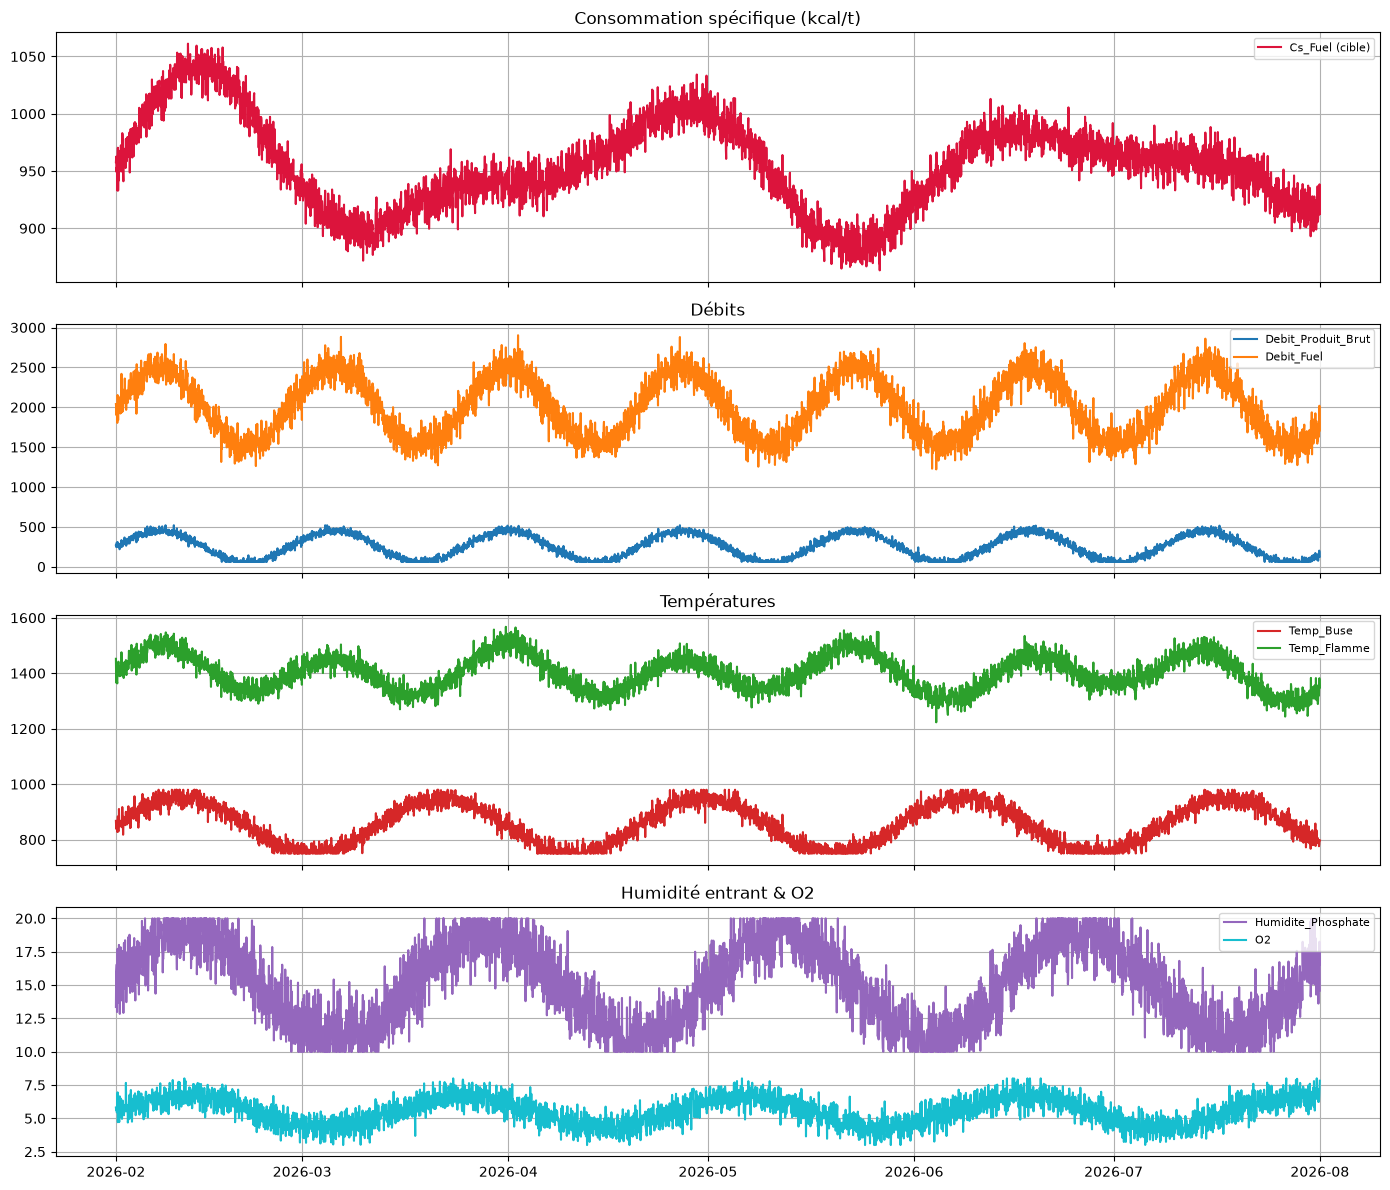

In [5]:
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(14, 12))

axes[0].plot(df.index, df['Cs_Fuel'], label='Cs_Fuel (cible)', color='crimson')
axes[0].set_title('Consommation spécifique (kcal/t)')

axes[1].plot(df.index, df['Debit_Produit_Brut'], label='Debit_Produit_Brut', color='tab:blue')
axes[1].plot(df.index, df['Debit_Fuel'], label='Debit_Fuel', color='tab:orange')
axes[1].set_title('Débits')

axes[2].plot(df.index, df['Temp_Buse'], label='Temp_Buse', color='tab:red')
axes[2].plot(df.index, df['Temp_Flamme'], label='Temp_Flamme', color='tab:green')
axes[2].set_title('Températures')

axes[3].plot(df.index, df['Humidite_Phosphate'], label='Humidite_Phosphate', color='tab:purple')
axes[3].plot(df.index, df['O2'], label='O2', color='tab:cyan')
axes[3].set_title('Humidité entrant & O2')

for ax in axes:
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('../models/eda_series.png', dpi=100)
plt.show()

## Matrice de corrélation

On regarde quelles variables sont corrélées avec la cible `Cs_Fuel` :
elles seront les candidats prioritaires du modèle XGBoost.

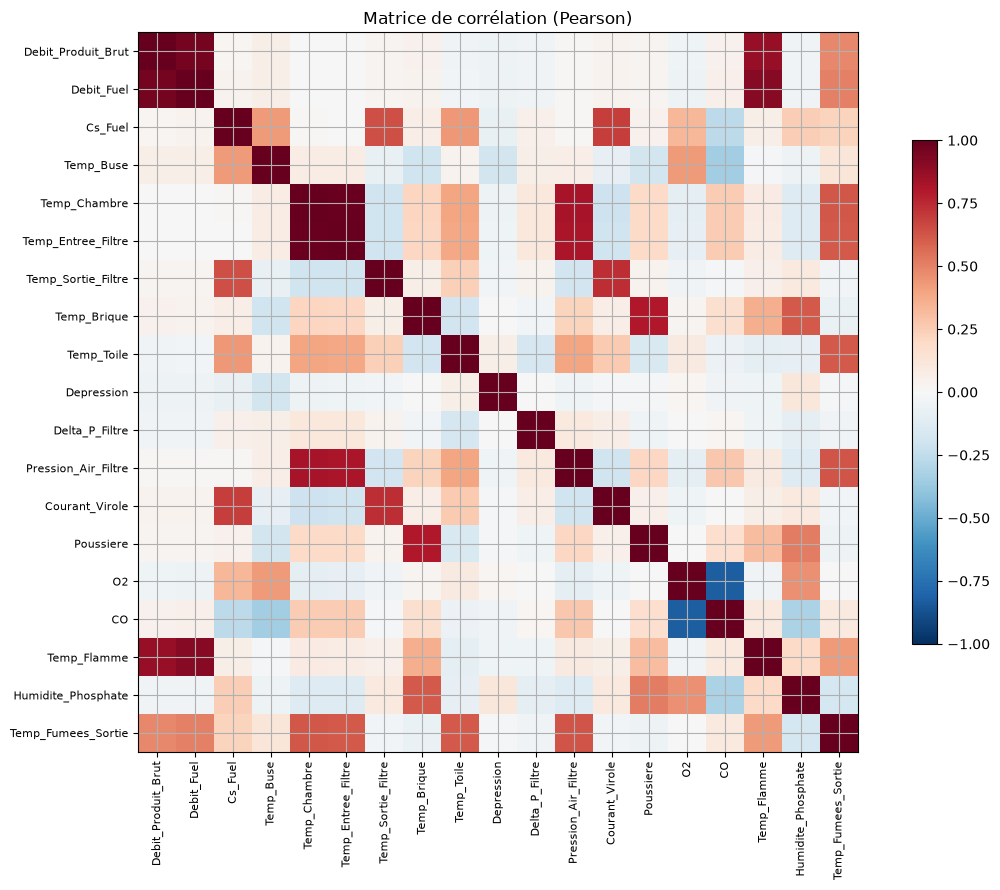

In [6]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
fig.colorbar(im, shrink=0.7)
plt.title('Matrice de corrélation (Pearson)')
plt.tight_layout()
plt.savefig('../models/eda_correlation.png', dpi=100)
plt.show()

In [7]:
print("Corrélations avec la cible Cs_Fuel (triées) :")
corr['Cs_Fuel'].sort_values(ascending=False).to_frame('corrélation')

Corrélations avec la cible Cs_Fuel (triées) :


,corrélation
Cs_Fuel,1.000000
Courant_Virole,0.691168
Temp_Sortie_Filtre,0.644502
Temp_Toile,0.435070
Temp_Buse,0.427873
O2,0.331525
Humidite_Phosphate,0.249298
Temp_Fumees_Sortie,0.221321
Temp_Brique,0.062835
Temp_Flamme,0.055498


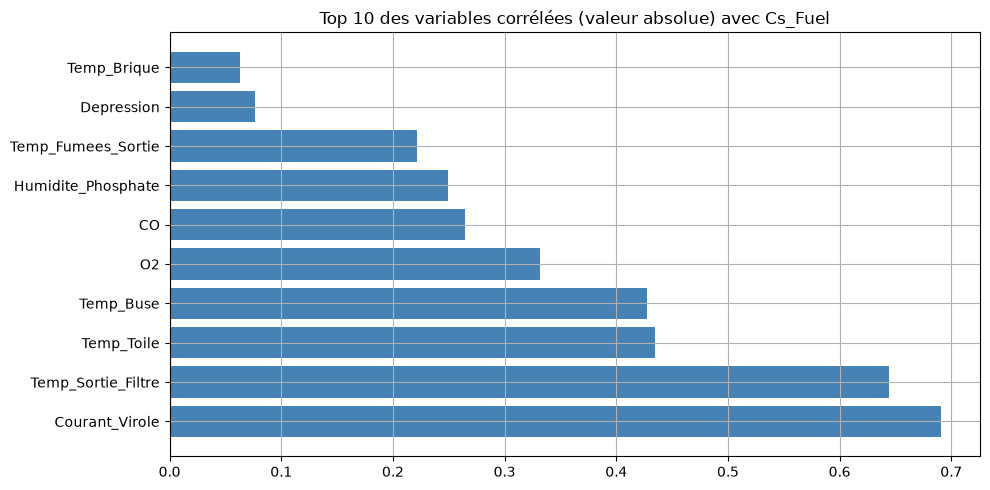

In [8]:
top = corr['Cs_Fuel'].drop('Cs_Fuel').abs().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top.index, top.values, color='steelblue')
ax.set_title('Top 10 des variables corrélées (valeur absolue) avec Cs_Fuel')
plt.tight_layout()
plt.savefig('../models/eda_top_corr.png', dpi=100)
plt.show()

## Détection des valeurs aberrantes

Méthode IQR (1,5 × écart interquartile) : on compte les points hors bornes
pour chaque variable. Si une variable dépasse ~1 % d'outliers, on la contrôlera
avant l'entraînement.

In [9]:
def detecter_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    borne_min, borne_max = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return s[(s < borne_min) | (s > borne_max)]

outliers = {col: len(detecter_outliers(df[col])) for col in df.columns}
res = pd.Series(outliers).to_frame('nb_outliers')
res['pct'] = (res['nb_outliers'] / len(df) * 100).round(2)
res.sort_values('pct', ascending=False)

,nb_outliers,pct
CO,5,0.12
Cs_Fuel,1,0.02
Debit_Produit_Brut,0,0.00
Debit_Fuel,0,0.00
Temp_Buse,0,0.00
Temp_Entree_Filtre,0,0.00
Temp_Chambre,0,0.00
Temp_Brique,0,0.00
Temp_Toile,0,0.00
Depression,0,0.00


In [10]:
print("Variables avec > 1% d'outliers (à surveiller) :")
liste = res[res['pct'] > 1]
print(liste if not liste.empty else "Aucune")

Variables avec > 1% d'outliers (à surveiller) :
Aucune


## Conclusion EDA

- Dataset propre : **0 valeur manquante**, périodicité horaire complète (182 jours).
- `Cs_Fuel` (cible) varie dans **863 – 1061 kcal/t**, cohérent avec le sujet (800–1100).
- Variables les plus liées à la cible (voir corrélations) :
  à compléter avec les résultats du notebook (ex. humidité entrant, T° fumées sortie...).
- Prochaine étape : bilan enthalpique + feature engineering puis entraînement XGBoost.